Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Load dataset from sklearn

In [2]:
data = load_diabetes()
X=data.data
y=data.target
df=pd.DataFrame(X, columns=data.feature_names)
df['target']=y
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [3]:
print("Shape of features: ", X.shape)
print("Shape of target: ", y.shape)
print("\nFeature Names: ")
print(data.feature_names)

Shape of features:  (442, 10)
Shape of target:  (442,)

Feature Names: 
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                test_size=0.2, random_state=42)

In [5]:
print("training data size: ", X_train.shape)
print("testing data size: ", X_test.shape)

training data size:  (353, 10)
testing data size:  (89, 10)


In [6]:
model = LinearRegression()

In [7]:
model.fit(X_train, y_train)

LinearRegression()

In [8]:
print("Intercept (c):", model.intercept_)

Intercept (c): 151.34560453985995


In [9]:
print("\nCoeficients: ")
for feature, coef in zip(data.feature_names, model.coef_):
    print(feature, ":", coef)


Coeficients: 
age : 37.904021350074984
sex : -241.96436231273995
bmi : 542.4287585162899
bp : 347.70384391385636
s1 : -931.4888458835163
s2 : 518.0622769833376
s3 : 163.41998299131035
s4 : 275.3179015786484
s5 : 736.1988589046839
s6 : 48.67065743196543


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("First 5 predictions: ", y_pred[:5])
print("Actual values: ", y_test[:5])

First 5 predictions:  [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]
Actual values:  [219.  70. 202. 230. 111.]


Evaluation metrics

In [12]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [13]:
print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)

Mean Squared Error:  2900.193628493482
R2 Score:  0.4526027629719195


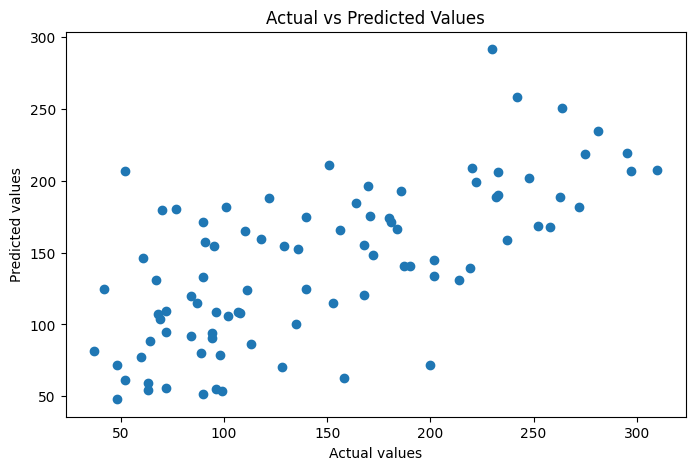

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted Values")
plt.show()